# **Patient Table**

In [ ]:
import pandas as pd
import numpy as np


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
patient = pd.read_csv("patient.csv.gz", compression='gzip')
patient

FileNotFoundError: [Errno 2] No such file or directory: 'patient.csv.gz'

In [ ]:
patient = patient.drop_duplicates()
assert patient['patientunitstayid'].duplicated().sum() == 0
patient.shape


In [ ]:
categorical_cols = patient.select_dtypes(include='object').columns

for col in categorical_cols:
    patient[col] = (
        patient[col]
        .astype(str)
        .str.lower()
        .str.strip()
    )

patient.head()


In [ ]:
patient['hospitaldischargestatus'] = patient['hospitaldischargestatus'].map({
    'alive': 0,
    'expired': 1
})

patient[['hospitaldischargestatus']].head()


In [ ]:
patient['age'] = patient['age'].replace('> 89', 90)
patient['age'] = pd.to_numeric(patient['age'], errors='coerce')

patient[['age']].describe()


In [ ]:
patient['age_group'] = pd.cut(
    patient['age'],
    bins=[0, 30, 50, 70, 90, 120],
    labels=['<30', '30-50', '50-70', '70-90', '90+']
)

patient[['age', 'age_group']].head()


In [ ]:
if 'gender' in patient.columns:
    patient['gender'] = patient['gender'].replace({
        'male': 1,
        'female': 0
    })

patient[['gender']].head()


In [ ]:
if 'unitdischargeoffset' in patient.columns:
    patient = patient.drop(columns=['unitdischargeoffset'])

if 'hospitaldischargeoffset' in patient.columns:
    patient = patient.drop(columns=['hospitaldischargeoffset'])

patient.shape


In [ ]:
assert patient['patientunitstayid'].nunique() == patient.shape[0]

patient.head()


In [ ]:
patient.to_csv('patient.csv', index=False)
patient1=pd.read_csv('patient.csv')
patient1.columns


# **Admissions Table**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
patient=pd.read_csv("patient.csv")
admission_df = pd.read_csv("admissionDx.csv.gz")
patient.head() #age group is at last target isnt at last!!

In [ ]:
assert patient['patientunitstayid'].nunique() == patient.shape[0]
baseline_count = patient.shape[0]


In [ ]:
admission_clean = admission_df[admission_df['admitdxenteredoffset'] >= 0].copy()


In [ ]:
admission_24h = admission_clean[
    admission_clean['admitdxenteredoffset'] <= 1440
].copy()


In [ ]:
admission_24h['admitdxpath'] = (
    admission_24h['admitdxpath']
    .str.lower()
    .str.strip()
)

In [ ]:
admission_24h = admission_clean[
    (admission_clean['admitdxenteredoffset'] >= 0) &
    (admission_clean['admitdxenteredoffset'] <= 1440)
].copy()

print("Admissions after 24h filter:", admission_24h.shape[0])

In [ ]:
admission_24h['path_depth'] = (
    admission_24h['admitdxpath'].str.count('\|') + 1
)


In [ ]:
admission_features = admission_24h.groupby('patientunitstayid').agg(
    admissiondx_count_24h=('admissiondxid', 'count'),
    unique_admissiondx_count_24h=('admitdxname', 'nunique'),
    earliest_admitdx_offset_24h=('admitdxenteredoffset', 'min'),
    latest_admitdx_offset_24h=('admitdxenteredoffset', 'max'),
    mean_admitdx_path_depth_24h=('path_depth', 'mean')
).reset_index()


In [ ]:
final_dataset = patient.merge(
    admission_features,
    on='patientunitstayid',
    how='left'
)

assert final_dataset.shape[0] == baseline_count


In [ ]:
final_dataset['admissiondx_count_24h'] = final_dataset['admissiondx_count_24h'].fillna(0)
final_dataset['unique_admissiondx_count_24h'] = final_dataset['unique_admissiondx_count_24h'].fillna(0)


In [ ]:
print("Rows after join:", final_dataset.shape[0])
print("Duplicate IDs:", final_dataset['patientunitstayid'].duplicated().sum())

print("Admission feature block complete.")


In [ ]:
admission_features.to_csv('admission_features.csv', index=False)

# **Diagnosis table**

In [ ]:
patient=pd.read_csv("patient.csv")
diagnosis_df = pd.read_csv("diagnosis.csv.gz", compression='gzip')


In [ ]:
diagnosis_df.columns


In [ ]:
assert patient['patientunitstayid'].nunique() == patient.shape[0]
baseline_count = patient.shape[0]

In [ ]:
diagnosis_clean = diagnosis_df[
    diagnosis_df['diagnosisoffset'] >= 0
].copy()

In [ ]:
diagnosis_24h = diagnosis_clean[
    diagnosis_clean['diagnosisoffset'] <= 1440
].copy()

print("Rows after 24h filtering:", diagnosis_24h.shape[0])

In [ ]:
diagnosis_24h['diagnosisstring'] = (
    diagnosis_24h['diagnosisstring']
    .astype(str)
    .str.lower()
    .str.strip()
)

diagnosis_24h['diagnosispriority'] = (
    diagnosis_24h['diagnosispriority']
    .astype(str)
    .str.lower()
    .str.strip()
)


In [ ]:
diagnosis_24h['dx_path_depth'] = (
    diagnosis_24h['diagnosisstring'].str.count('\|') + 1
)

In [ ]:
diagnosis_24h['is_primary'] = (
    diagnosis_24h['diagnosispriority'] == 'primary'
).astype(int)

diagnosis_24h['is_major'] = (
    diagnosis_24h['diagnosispriority'] == 'major'
).astype(int)

diagnosis_24h['is_other'] = (
    diagnosis_24h['diagnosispriority'] == 'other'
).astype(int)


In [ ]:
diagnosis_features = diagnosis_24h.groupby('patientunitstayid').agg(
    diagnosis_count_24h=('diagnosisid', 'count'),
    unique_diagnosis_count_24h=('diagnosisstring', 'nunique'),
    primary_dx_count_24h=('is_primary', 'sum'),
    major_dx_count_24h=('is_major', 'sum'),
    other_dx_count_24h=('is_other', 'sum'),
    earliest_dx_offset_24h=('diagnosisoffset', 'min'),
    mean_dx_path_depth_24h=('dx_path_depth', 'mean')
).reset_index()

print("Diagnosis feature rows:", diagnosis_features.shape[0])

In [ ]:
final_dataset = patient.merge(
    diagnosis_features,
    on='patientunitstayid',
    how='left'
)

assert final_dataset.shape[0] == baseline_count


In [ ]:
count_columns = [
    'diagnosis_count_24h',
    'unique_diagnosis_count_24h',
    'primary_dx_count_24h',
    'major_dx_count_24h',
    'other_dx_count_24h'
]

for col in count_columns:
    final_dataset[col] = final_dataset[col].fillna(0)


In [ ]:
print("Rows after join:", final_dataset.shape[0])
print("Duplicate patient IDs:",
      final_dataset['patientunitstayid'].duplicated().sum())

print("Diagnosis feature block complete.")
final_dataset.to_csv('finaldataset1.csv', index=False)

In [ ]:
finaldataset1=pd.read_csv('finaldataset1.csv')
finaldataset1.columns

# **Vital Periodic Table**

In [ ]:
import pandas as pd
patient=pd.read_csv("patient.csv")

vital_periodic_df = pd.read_csv("vitalPeriodic.csv.gz")


In [ ]:
vital_periodic_df.columns


In [ ]:
import pandas as pd
import numpy as np

In [ ]:

vital_df = pd.read_csv("vitalPeriodic.csv.gz")

In [ ]:
assert patient['patientunitstayid'].nunique() == patient.shape[0]
baseline_count = patient.shape[0]


In [ ]:
vital_24h = vital_df[
    (vital_df['observationoffset'] >= 0) &
    (vital_df['observationoffset'] <= 1440)
].copy()

print("Rows after 24h filter:", vital_24h.shape[0])


In [ ]:
# Heart Rate (25–250)
vital_24h.loc[
    (vital_24h['heartrate'] < 25) |
    (vital_24h['heartrate'] > 250),
    'heartrate'
] = np.nan

In [ ]:
# Respiration (5–80)
vital_24h.loc[
    (vital_24h['respiration'] < 5) |
    (vital_24h['respiration'] > 80),
    'respiration'
] = np.nan

In [ ]:
# SpO2 (50–100)
vital_24h.loc[
    (vital_24h['sao2'] < 50) |
    (vital_24h['sao2'] > 100),
    'sao2'
] = np.nan

# Temperature (30–43 Celsius)
vital_24h.loc[
    (vital_24h['temperature'] < 30) |
    (vital_24h['temperature'] > 43),
    'temperature'
] = np.nan

# Systolic BP (50–300)
vital_24h.loc[
    (vital_24h['systemicsystolic'] < 50) |
    (vital_24h['systemicsystolic'] > 300),
    'systemicsystolic'
] = np.nan

# Diastolic BP (30–200)
vital_24h.loc[
    (vital_24h['systemicdiastolic'] < 30) |
    (vital_24h['systemicdiastolic'] > 200),
    'systemicdiastolic'
] = np.nan

# Mean BP (40–250)
vital_24h.loc[
    (vital_24h['systemicmean'] < 40) |
    (vital_24h['systemicmean'] > 250),
    'systemicmean'
] = np.nan

# CVP (-5 to 40)
vital_24h.loc[
    (vital_24h['cvp'] < -5) |
    (vital_24h['cvp'] > 40),
    'cvp'
] = np.nan

# ETCO2 (10–100)
vital_24h.loc[
    (vital_24h['etco2'] < 10) |
    (vital_24h['etco2'] > 100),
    'etco2'
] = np.nan

# ICP (0–60)
vital_24h.loc[
    (vital_24h['icp'] < 0) |
    (vital_24h['icp'] > 60),
    'icp'
] = np.nan


In [ ]:
vital_cols = [
    'heartrate',
    'respiration',
    'sao2',
    'temperature',
    'systemicsystolic',
    'systemicdiastolic',
    'systemicmean',
    'cvp',
    'etco2',
    'icp'
]

In [ ]:
vital_features = vital_24h.groupby('patientunitstayid')[vital_cols].agg(
    ['mean', 'min', 'max', 'std']
)

# Flatten column names
vital_features.columns = [
    f"{col}_{stat}_24h"
    for col, stat in vital_features.columns
]

vital_features = vital_features.reset_index()

print("Vital feature rows:", vital_features.shape)
vital_features.to_csv('vital_features.csv', index=False)


In [ ]:
final_dataset = finaldataset1.merge(
    vital_features,
    on='patientunitstayid',
    how='left'
)

assert final_dataset.shape[0] == baseline_count

print("Rows after join:", final_dataset.shape[0])
print("Duplicate IDs:",
      final_dataset['patientunitstayid'].duplicated().sum())

print("Vital feature engineering complete.")

# Lab Table

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
lab_df=pd.read_csv('lab.csv.gz')

lab_df

In [ ]:
lab_df.head()
lab_df.info()
lab_df["labname"].value_counts().head(20)

In [ ]:
lab_df["labresult"] = pd.to_numeric(lab_df["labresult"], errors="coerce")
lab_df = lab_df.dropna(subset=["labresult"])
lab_df = lab_df[lab_df["labname"] != "#NAME?"]
lab_df["labname"] = lab_df["labname"].str.lower().str.strip()

In [ ]:
lab_df = lab_df.dropna(subset=["labresult"])

In [ ]:
lab_df_24h = lab_df[
    (lab_df["labresultoffset"] >= 0) &
    (lab_df["labresultoffset"] <= 24 * 60)
]

In [ ]:
lab_ranges = {
    "creatinine": (0.1, 20),
    "platelets x 1000": (5, 2000),
    "bedside glucose": (20, 1000),
    "troponin - i": (0, 100),
    "hct": (5, 70)
}

for lab, (low, high) in lab_ranges.items():
    mask = lab_df_24h["labname"] == lab
    lab_df_24h.loc[
        mask &
        ((lab_df_24h["labresult"] < low) |
         (lab_df_24h["labresult"] > high)),
        "labresult"
    ] = np.nan

lab_df_24h = lab_df_24h.dropna(subset=["labresult"])


In [ ]:
important_labs = [
    "creatinine",
    "platelets x 1000",
    "bedside glucose",
    "troponin - i",
    "hct"
]

lab_df_24h = lab_df_24h[
    lab_df_24h["labname"].isin(important_labs)
]

In [ ]:
lab_features = lab_df_24h.groupby(
    ["patientunitstayid", "labname"]
)["labresult"].agg(["mean", "max", "min", "std"]).reset_index()


In [ ]:
lab_features = lab_features.pivot(
    index="patientunitstayid",
    columns="labname"
)

lab_features.columns = [
    f"{lab}_{stat}"
    for lab, stat in lab_features.columns
]

lab_features = lab_features.reset_index()


In [ ]:
lab_features["aki_flag"] = (
    lab_features["max_creatinine"] > 2
).astype(int)

In [ ]:
lab_features["low_platelets"] = (
    lab_features["min_platelets x 1000"] < 100
).astype(int)

In [ ]:
lab_features["hyperglycemia"] = (
    lab_features["std_bedside glucose"] > 180
).astype(int)


In [ ]:
lab_features["cardiac_injury"] = (
    lab_features["min_troponin - i"] > 0.04
).astype(int)
lab_features.to_csv('lab.csv', index=False)


In [ ]:
final_df = final_dataset.merge(
    lab_features,
    on="patientunitstayid",
    how="left"
)
final_df = final_df.fillna(0)

In [ ]:
final_df

# **Medication table**

In [ ]:
!wget -r -N -c -np https://physionet.org/files/eicu-crd-demo/2.0.1/sqlite/

In [ ]:

!gunzip /content/physionet.org/files/eicu-crd-demo/2.0.1/sqlite/*.gz

In [ ]:
import sqlite3

conn = sqlite3.connect(
    "/content/physionet.org/files/eicu-crd-demo/2.0.1/sqlite/eicu_v2_0_1.sqlite3"
)

In [ ]:
cursor = conn.cursor()

cursor.execute("""
SELECT name FROM sqlite_master WHERE type='table';
""")

print(cursor.fetchall())

In [ ]:
import pandas as pd

pd.read_sql_query("PRAGMA table_info(medication);", conn)

In [ ]:
df_med = pd.read_sql_query(
"""
SELECT *
FROM medication
LIMIT 10
""",
conn)

df_med.head()

In [ ]:
query = """
SELECT
    medicationid,
    patientunitstayid,
    drugstartoffset,
    drugstopoffset,
    drugordercancelled,
    drugname,
    dosage,
    routeadmin,
    frequency,
    prn
FROM medication
"""
df_med = pd.read_sql_query(query, conn)

In [ ]:
df_med = df_med[df_med["drugordercancelled"] == "No"].copy()

In [ ]:
df_med = pd.read_sql_query(
"""
SELECT *
FROM medication
LIMIT 10
""",
conn)

df_med.head()

In [ ]:
df_med["duration"] = (
    df_med["drugstopoffset"] - df_med["drugstartoffset"]
)

In [ ]:
df_med["routeadmin"] = df_med["routeadmin"].str.lower().str.strip()
df_med["frequency"] = df_med["frequency"].str.lower().str.strip()

In [ ]:
query = """
SELECT
    patientunitstayid,
    age,
    gender,
    hospitaldischargestatus,
    apacheadmissiondx
FROM patient
"""
df_patient = pd.read_sql_query(query, conn)

In [ ]:
df = df_med.merge(
    df_patient,
    on="patientunitstayid",
    how="left"
)

In [ ]:
import pandas as pd
import sqlite3

# Assuming 'conn' is your active SQLite connection object
# If not, you would need to establish it:
# conn = sqlite3.connect('/content/physionet.org/files/eicu-crd-demo/2.0.1/sqlite/eicu_v2_0_1.sqlite3')

# Replace 'medication' with the name of the table you want to convert
table_name = 'medication'
df_from_sqlite = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

print(f"Successfully loaded table '{table_name}' into a DataFrame with {df_from_sqlite.shape[0]} rows and {df_from_sqlite.shape[1]} columns.")
display(df_from_sqlite.head())

In [ ]:
df.head()

In [ ]:
df.columns

In [ ]:
df.shape

In [ ]:
df[["age","gender"]].isnull().sum()

In [ ]:
import sqlite3

# choose output file name
output_path = "/content/cleaned_medication_patient.sqlite3"

# create sqlite database
conn_out = sqlite3.connect(output_path)

# save dataframe
df.to_sql(
    "cleaned_medication_patient",   # table name inside sqlite
    conn_out,
    index=False,
    if_exists="replace"
)

conn_out.close()

print("Saved at:", output_path)

In [ ]:
conn_check = sqlite3.connect("/content/cleaned_medication_patient.sqlite3")
cursor = conn_check.cursor()

In [ ]:
cursor.execute("""
SELECT name FROM sqlite_master WHERE type='table';
""")

print(cursor.fetchall())

In [ ]:
pd.read_sql_query(
"SELECT COUNT(*) as total_rows FROM cleaned_medication_patient",
conn_check
)

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
pd.read_sql_query(
"PRAGMA table_info(cleaned_medication_patient);",
conn_check
)

In [ ]:
import sqlite3
import pandas as pd

# Connect to the cleaned medication patient SQLite database
conn_med = sqlite3.connect('/content/cleaned_medication_patient.sqlite3')

# Load the 'cleaned_medication_patient' table into a DataFrame
medication_features = pd.read_sql_query("SELECT * FROM cleaned_medication_patient", conn_med)

conn_med.close()

print(f"Medication features loaded: {medication_features.shape[0]} rows, {medication_features.shape[1]} columns")
display(medication_features.head())

In [ ]:
# Merge medication_features with final_df
final_df = final_df.merge(
    medication_features,
    on='patientunitstayid',
    how='left'
)

print(f"Final dataset after merging medication features: {final_df.shape[0]} rows, {final_df.shape[1]} columns")
display(final_df.head())

In [ ]:
final_df.to_csv('final_df.csv', index=False)
print("final_df saved to 'final_df.csv'")

In [ ]:
final_df2=pd.read_csv('final_df.csv')

In [ ]:
final_df.columns == final_df2.columns

In [ ]:
#Team 2 just created objects so we had to save and edit errors for each table also somehow last 2 tables used other format than earlier ones likely due to splitting the tasks while not coordinating
#so it took some time for team 3.

Team 3: LSTM


In [2]:
import pandas as pd

print(" Reloading final_df from CSV...")
final_df = pd.read_csv('/content/drive/MyDrive/final_df.csv')

print(" Removing data leakage columns...")

# Define all leakage columns
leakage_cols = [
    'hospitaldischargeyear',
    'hospitaldischargetime24',
    'hospitaldischargelocation',
    'dischargeweight',
    'unitdischargetime24',
    'unitdischargelocation',
    'unitdischargestatus',
]

# Only drop columns that exist
cols_to_drop = [col for col in leakage_cols if col in final_df.columns]

if cols_to_drop:
    print(f"   Dropping {len(cols_to_drop)} leakage columns:")
    for col in cols_to_drop:
        print(f"      ❌ {col}")
    final_df = final_df.drop(columns=cols_to_drop)
    print(f"✅ Leakage columns removed")
else:
    print("✅ No leakage columns found (already removed)")

print(f"   Remaining columns: {len(final_df.columns)}")

 Reloading final_df from CSV...
 Removing data leakage columns...
   Dropping 7 leakage columns:
      ❌ hospitaldischargeyear
      ❌ hospitaldischargetime24
      ❌ hospitaldischargelocation
      ❌ dischargeweight
      ❌ unitdischargetime24
      ❌ unitdischargelocation
      ❌ unitdischargestatus
✅ Leakage columns removed
   Remaining columns: 111


In [3]:
print("Preparing target variable...")

# Check if target exists
if 'hospitaldischargestatus_x' not in final_df.columns:
    print(" ERROR: 'hospitaldischargestatus_x' column not found!")
    print("   Available columns:", final_df.columns.tolist())
    exit()

# Verify encoding
print(f"   Target variable: hospitaldischargestatus_x")
print(f"   Value counts:\n{final_df['hospitaldischargestatus_x'].value_counts()}")

# Ensure binary encoding
if final_df['hospitaldischargestatus_x'].dtype == 'object':
    print("   Converting to numeric (Alive=0, Expired=1)...")
    final_df['hospitaldischargestatus_x'] = final_df['hospitaldischargestatus_x'].map({
        'alive': 0, 'Alive': 0, 'ALIVE': 0,
        'expired': 1, 'Expired': 1, 'EXPIRED': 1
    })

# Calculate mortality rate
mortality_rate = final_df['hospitaldischargestatus_x'].mean() * 100
print(f"✅ Mortality rate: {mortality_rate:.2f}%")
print(f"   Class balance: {final_df['hospitaldischargestatus_x'].value_counts().to_dict()}")

Preparing target variable...
   Target variable: hospitaldischargestatus_x
   Value counts:
hospitaldischargestatus_x
0.0    2316
1.0     212
Name: count, dtype: int64
✅ Mortality rate: 8.39%
   Class balance: {0.0: 2316, 1.0: 212}


In [4]:
print("Identifying columns to exclude from modeling...")

# Columns to exclude from features
identifier_cols = [
    'patientunitstayid',
    'patienthealthsystemstayid',
    'uniquepid',
    'hospitalid',
    'wardid'
]

# Keep these aside
exclude_cols = [col for col in identifier_cols if col in final_df.columns]
exclude_cols.append('hospitaldischargestatus_x')  # Add target with correct name

print(f"   Identifier columns (not features): {len(exclude_cols)-1}")
for col in exclude_cols[:-1]:  # Don't print target
    print(f"       {col}")
print(f"   Target column: hospitaldischargestatus_x")

Identifying columns to exclude from modeling...
   Identifier columns (not features): 5
       patientunitstayid
       patienthealthsystemstayid
       uniquepid
       hospitalid
       wardid
   Target column: hospitaldischargestatus_x


In [5]:
print("Encoding categorical variables...")

# Get all columns except identifiers and target
feature_cols = [col for col in final_df.columns if col not in exclude_cols]

# Identify categorical columns
categorical_cols = final_df[feature_cols].select_dtypes(include=['object']).columns.tolist()

print(f"   Found {len(categorical_cols)} categorical columns:")
for col in categorical_cols:
    n_unique = final_df[col].nunique()
    print(f"      📝 {col}: {n_unique} unique values")

# One-hot encode categorical variables
if categorical_cols:
    print(f"\n   Applying one-hot encoding...")
    final_df_encoded = pd.get_dummies(
        final_df,
        columns=categorical_cols,
        drop_first=True,  # Avoid multicollinearity
        prefix_sep='_',
        dummy_na=False  # Don't create separate column for NaN
    )
    print(f"✅ One-hot encoding complete")
    print(f"   Columns before: {len(final_df.columns)}")
    print(f"   Columns after: {len(final_df_encoded.columns)}")
    final_df = final_df_encoded
else:
    print("   No categorical columns to encode")



Encoding categorical variables...
   Found 19 categorical columns:
      📝 ethnicity: 7 unique values
      📝 apacheadmissiondx_x: 237 unique values
      📝 hospitaladmittime24: 1339 unique values
      📝 hospitaladmitsource: 14 unique values
      📝 unittype: 8 unique values
      📝 unitadmittime24: 1148 unique values
      📝 unitadmitsource: 14 unique values
      📝 unitstaytype: 4 unique values
      📝 age_group: 5 unique values
      📝 drugivadmixture: 1 unique values
      📝 drugordercancelled: 1 unique values
      📝 drugname: 8 unique values
      📝 dosage: 6 unique values
      📝 routeadmin: 2 unique values
      📝 frequency: 5 unique values
      📝 prn: 2 unique values
      📝 gender_y: 2 unique values
      📝 hospitaldischargestatus_y: 1 unique values
      📝 apacheadmissiondx_y: 2 unique values

   Applying one-hot encoding...
✅ One-hot encoding complete
   Columns before: 111
   Columns after: 2879


In [6]:
print("Handling missing values...")
import numpy as np
# Get feature columns (excluding identifiers and target)
feature_cols = [col for col in final_df.columns if col not in exclude_cols]

# Calculate missing percentage
missing_pct = (final_df[feature_cols].isnull().sum() / len(final_df) * 100).sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 50]

if len(high_missing) > 0:
    print(f"   Columns with >50% missing data: {len(high_missing)}")
    for col, pct in high_missing.head(10).items():
        print(f"      ⚠️  {col}: {pct:.1f}% missing")

# Strategy: Median imputation for numerical, mode for categorical
print("\n   Applying imputation strategy...")

# For numerical columns
numerical_cols = final_df[feature_cols].select_dtypes(include=[np.number]).columns
print(f"   Imputing {len(numerical_cols)} numerical columns with median...")

for col in numerical_cols:
    if final_df[col].isnull().any():
        median_val = final_df[col].median()
        final_df[col].fillna(median_val, inplace=True)

# Check for any remaining missing values
remaining_missing = final_df[feature_cols].isnull().sum().sum()
print(f"✅ Imputation complete. Remaining missing values: {remaining_missing}")

if remaining_missing > 0:
    print("   Filling remaining missing values with 0...")
    final_df[feature_cols] = final_df[feature_cols].fillna(0)


Handling missing values...
   Columns with >50% missing data: 9
      ⚠️  loadingdose: 100.0% missing
      ⚠️  drugstopoffset: 99.6% missing
      ⚠️  gtc: 99.6% missing
      ⚠️  duration: 99.6% missing
      ⚠️  age_y: 99.6% missing
      ⚠️  drugstartoffset: 99.6% missing
      ⚠️  drugorderoffset: 99.6% missing
      ⚠️  drughiclseqno: 99.6% missing
      ⚠️  medicationid: 99.6% missing

   Applying imputation strategy...
   Imputing 86 numerical columns with median...
✅ Imputation complete. Remaining missing values: 2528
   Filling remaining missing values with 0...


/tmp/ipython-input-767671718.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df[col].fillna(median_val, inplace=True)


In [7]:
final_df.columns

Index(['patientunitstayid', 'patienthealthsystemstayid', 'gender_x', 'age_x',
       'hospitalid', 'wardid', 'admissionheight', 'hospitaladmitoffset',
       'hospitaldischargestatus_x', 'unitvisitnumber',
       ...
       'dosage_75 3', 'dosage_81 3', 'routeadmin_po', 'frequency_once prn',
       'frequency_q evening', 'frequency_q15 min prn', 'frequency_q6h sch',
       'prn_Yes', 'gender_y_Male',
       'apacheadmissiondx_y_Rhythm disturbance (atrial, supraventricular)'],
      dtype='object', length=2879)

In [8]:
print("Preparing final feature matrix...")

# Extract features (X) and target (y)
y = final_df['hospitaldischargestatus_x'].copy()
X = final_df.drop(columns=exclude_cols).copy()

print(f"✅ Feature matrix prepared")
print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")
print(f"   Total feature columns: {len(X.columns)}")

# Save feature names for later use
feature_names = X.columns.tolist()
print(f"\n   Saving feature names to 'feature_names.txt'...")
with open('feature_names.txt', 'w') as f:
    for fname in feature_names:
        f.write(fname + '\n')

Preparing final feature matrix...
✅ Feature matrix prepared
   Features (X): (2528, 2873)
   Target (y): (2528,)
   Total feature columns: 2873

   Saving feature names to 'feature_names.txt'...


In [9]:
print("Creating train/validation/test splits...")
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class balance
)

# Second split: Split temp into 60% train, 20% val (75% of temp = 60% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of total
    random_state=42,
    stratify=y_temp
)

print(f"✅ Data split complete:")
print(f"   Train: {X_train.shape[0]:,} patients ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]:,} patients ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test: {X_test.shape[0]:,} patients ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class balance
print(f"\n   Class distribution:")
print(f"   Train - Deaths: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"   Val - Deaths: {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"   Test - Deaths: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")


Creating train/validation/test splits...
✅ Data split complete:
   Train: 1,516 patients (60.0%)
   Validation: 506 patients (20.0%)
   Test: 506 patients (20.0%)

   Class distribution:
   Train - Deaths: 127.0 (8.38%)
   Val - Deaths: 43.0 (8.50%)
   Test - Deaths: 42.0 (8.30%)


In [10]:
print("Saving preprocessed data for XGBoost...")

# Save as CSV
pd.DataFrame(X_train).to_csv('X_train_xgboost.csv', index=False)
pd.DataFrame(X_val).to_csv('X_val_xgboost.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test_xgboost.csv', index=False)

pd.Series(y_train).to_csv('y_train.csv', index=False)
pd.Series(y_val).to_csv('y_val.csv', index=False)
pd.Series(y_test).to_csv('y_test.csv', index=False)

print(f"✅ XGBoost data saved:")
print(f"   X_train_xgboost.csv, X_val_xgboost.csv, X_test_xgboost.csv")
print(f"   y_train.csv, y_val.csv, y_test.csv")

# Also save as NumPy arrays for faster loading
np.save('X_train_xgboost.npy', X_train)
np.save('X_val_xgboost.npy', X_val)
np.save('X_test_xgboost.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

print(f"   Also saved as .npy files for faster loading")

Saving preprocessed data for XGBoost...
✅ XGBoost data saved:
   X_train_xgboost.csv, X_val_xgboost.csv, X_test_xgboost.csv
   y_train.csv, y_val.csv, y_test.csv
   Also saved as .npy files for faster loading


In [11]:
print("\n" + "="*80)
print("PREPARING TEMPORAL SEQUENCES FOR LSTM")
print("="*80)

print(" Loading temporal data for LSTM...")

# LSTM requires time-series data, not aggregated statistics

try:
    # Load raw vital signs
    print("   Loading raw vitalPeriodic.csv...")
    vital_raw = pd.read_csv('/content/drive/MyDrive/vitalPeriodic.csv')
    print(f"   ✅ Loaded: {vital_raw.shape}")

    # Load raw labs
    print("   Loading raw lab.csv...")
    lab_raw = pd.read_csv('/content/drive/MyDrive/lab.csv')
    print(f"   ✅ Loaded: {lab_raw.shape}")

    # ------------------------------------------------------------------
    # 🔧 MINIMAL FIX: ensure X_* are pandas DataFrames so .index works
    import pandas as pd
    import numpy as np

    if isinstance(X_train, np.ndarray):
        X_train = pd.DataFrame(X_train)

    if isinstance(X_val, np.ndarray):
        X_val = pd.DataFrame(X_val)

    if isinstance(X_test, np.ndarray):
        X_test = pd.DataFrame(X_test)
    # ------------------------------------------------------------------

    # Get patient IDs from train/val/test
    train_ids = final_df.loc[X_train.index, 'patientunitstayid'].values
    val_ids   = final_df.loc[X_val.index,   'patientunitstayid'].values
    test_ids  = final_df.loc[X_test.index,  'patientunitstayid'].values

    print(f"\n   Patients to process:")
    print(f"      Train: {len(train_ids):,}")
    print(f"      Val: {len(val_ids):,}")
    print(f"      Test: {len(test_ids):,}")

    # FUNCTION: CREATE TEMPORAL SEQUENCES
    def create_temporal_sequences(patient_ids, vital_df, lab_df, window_hours=48):

        print(f"\n   Creating {window_hours}-hour sequences for {len(patient_ids):,} patients...")

        vital_vars = [
            'heartrate', 'respiration', 'sao2', 'temperature',
            'systemicsystolic', 'systemicdiastolic', 'systemicmean'
        ]

        lab_vars = ['bedside glucose', 'creatinine', 'hct', 'platelets x 1000']

        sequences = []
        valid_patient_ids = []

        for idx, patient_id in enumerate(patient_ids):
            if idx % 100 == 0:
                print(f"      Processing patient {idx+1}/{len(patient_ids)}...", end='\r')

            patient_vitals = vital_df[
                (vital_df['patientunitstayid'] == patient_id) &
                (vital_df['observationoffset'] >= 0) &
                (vital_df['observationoffset'] <= window_hours * 60)
            ].copy()

            patient_labs = lab_df[
                (lab_df['patientunitstayid'] == patient_id) &
                (lab_df['labresultoffset'] >= 0) &
                (lab_df['labresultoffset'] <= window_hours * 60)
            ].copy()

            hourly_data = []

            for hour in range(window_hours):
                hour_start = hour * 60
                hour_end   = (hour + 1) * 60

                hour_vitals = patient_vitals[
                    (patient_vitals['observationoffset'] >= hour_start) &
                    (patient_vitals['observationoffset'] < hour_end)
                ]

                hour_labs = patient_labs[
                    (patient_labs['labresultoffset'] >= hour_start) &
                    (patient_labs['labresultoffset'] < hour_end)
                ]

                hour_features = []

                # Vital means
                for var in vital_vars:
                    val = hour_vitals[var].mean() if var in hour_vitals.columns else np.nan
                    hour_features.append(val)

                # Lab means
                for var in lab_vars:
                    matching_labs = hour_labs[hour_labs['labname'].str.lower() == var.lower()]
                    val = pd.to_numeric(matching_labs['labresult'], errors='coerce').mean() if len(matching_labs) > 0 else np.nan
                    hour_features.append(val)

                hourly_data.append(hour_features)

            sequence = np.array(hourly_data)

            # Forward fill NaNs
            for col_idx in range(sequence.shape[1]):
                col_data = sequence[:, col_idx]
                mask = np.isnan(col_data)

                if not mask.all():
                    idx_good = np.where(~mask)[0]
                    if len(idx_good) > 0:
                        first_valid = col_data[idx_good[0]]
                        col_data[mask & (np.arange(len(col_data)) < idx_good[0])] = first_valid

                        for i in range(len(col_data)):
                            if np.isnan(col_data[i]) and i > 0:
                                col_data[i] = col_data[i-1]

                sequence[:, col_idx] = col_data

            sequence = np.nan_to_num(sequence, nan=0.0)

            sequences.append(sequence)
            valid_patient_ids.append(patient_id)

        print(f"\n   ✅ Sequences created for {len(sequences):,} patients")

        return np.array(sequences), valid_patient_ids


    # Create sequences
    print("\n" + "-"*80)
    print("Creating TRAIN sequences...")
    X_train_lstm, _ = create_temporal_sequences(train_ids, vital_raw, lab_raw)

    print("\nCreating VALIDATION sequences...")
    X_val_lstm, _ = create_temporal_sequences(val_ids, vital_raw, lab_raw)

    print("\nCreating TEST sequences...")
    X_test_lstm, _ = create_temporal_sequences(test_ids, vital_raw, lab_raw)


    # Normalize
    print("\nNormalizing LSTM sequences...")
    n_train, n_timesteps, n_features = X_train_lstm.shape

    scaler = StandardScaler()

    X_train_2d = X_train_lstm.reshape(-1, n_features)
    scaler.fit(X_train_2d)

    X_train_lstm_scaled = scaler.transform(X_train_2d).reshape(X_train_lstm.shape)
    X_val_lstm_scaled   = scaler.transform(X_val_lstm.reshape(-1, n_features)).reshape(X_val_lstm.shape)
    X_test_lstm_scaled  = scaler.transform(X_test_lstm.reshape(-1, n_features)).reshape(X_test_lstm.shape)

    print("✅ Normalization complete")


    # Save
    print("Saving LSTM sequences...")

    np.save('X_train_lstm.npy', X_train_lstm_scaled)
    np.save('X_val_lstm.npy',   X_val_lstm_scaled)
    np.save('X_test_lstm.npy',  X_test_lstm_scaled)

    import pickle
    with open('lstm_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    print("✅ LSTM data saved successfully")

except FileNotFoundError as e:
    print(f"\n⚠️  Could not create LSTM sequences: {e}")
    print("   You can still proceed with XGBoost only.")

except Exception as e:
    print(f"\n⚠️  Error creating LSTM sequences: {e}")



PREPARING TEMPORAL SEQUENCES FOR LSTM
 Loading temporal data for LSTM...
   Loading raw vitalPeriodic.csv...
   ✅ Loaded: (121464, 19)
   Loading raw lab.csv...
   ✅ Loaded: (86926, 10)

   Patients to process:
      Train: 1,516
      Val: 506
      Test: 506

--------------------------------------------------------------------------------
Creating TRAIN sequences...

   Creating 48-hour sequences for 1,516 patients...

   ✅ Sequences created for 1,516 patients

Creating VALIDATION sequences...

   Creating 48-hour sequences for 506 patients...

   ✅ Sequences created for 506 patients

Creating TEST sequences...

   Creating 48-hour sequences for 506 patients...

   ✅ Sequences created for 506 patients

Normalizing LSTM sequences...
✅ Normalization complete
Saving LSTM sequences...
✅ LSTM data saved successfully


In [12]:
import numpy as np

# Load sequences
X_train = np.load("X_train_lstm.npy")
X_val   = np.load("X_val_lstm.npy")
X_test  = np.load("X_test_lstm.npy")

# Load labels
y_train = np.load("y_train.npy")
y_val   = np.load("y_val.npy")
y_test  = np.load("y_test.npy")

print("Train:", X_train.shape, y_train.shape)
print("Val:",   X_val.shape, y_val.shape)
print("Test:",  X_test.shape, y_test.shape)



Train: (1516, 48, 11) (1516,)
Val: (506, 48, 11) (506,)
Test: (506, 48, 11) (506,)


Creating LSTM model

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_timesteps = X_train.shape[1]
n_features  = X_train.shape[2]

model = Sequential([
    Masking(mask_value=0.0, input_shape=(n_timesteps, n_features)),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")   # binary mortality
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["AUC","accuracy"]
)

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 48, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 48, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

Traning using early stopping and callback

In [14]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - AUC: 0.5421 - accuracy: 0.6558 - loss: 0.6234 - val_AUC: 0.4562 - val_accuracy: 0.9130 - val_loss: 0.3090 - learning_rate: 0.0010
Epoch 2/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.5245 - accuracy: 0.9136 - loss: 0.2964 - val_AUC: 0.5099 - val_accuracy: 0.9130 - val_loss: 0.2905 - learning_rate: 0.0010
Epoch 3/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.4713 - accuracy: 0.9044 - loss: 0.3220 - val_AUC: 0.5347 - val_accuracy: 0.9130 - val_loss: 0.2910 - learning_rate: 0.0010
Epoch 4/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.5068 - accuracy: 0.9109 - loss: 0.3050 - val_AUC: 0.5271 - val_accuracy: 0.9111 - val_loss: 0.2946 - learning_rate: 0.0010
Epoch 5/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - AUC: 0.5347 - accuracy: 0.9227 - loss: 0.2786 - val_AUC: 0.5417 - val_accuracy: 0.9111 - val_loss: 0.2914 - learning_rate: 0.0010
Epoch 6/60
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.5010 - accuracy: 0.9320 -

In [15]:
results = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Results")
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")



Test Results
loss: 0.2820
compile_metrics: 0.5619


In [16]:
lstm_prob = model.predict(X_test).ravel()
y_pred = (lstm_prob > 0.5).astype(int)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [17]:
from sklearn.metrics import roc_auc_score, classification_report

auc = roc_auc_score(y_test, lstm_prob)
print("AUROC:", auc)

print(classification_report(y_test, y_pred))


AUROC: 0.5472085385878489
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96       464
         1.0       0.00      0.00      0.00        42

    accuracy                           0.92       506
   macro avg       0.46      0.50      0.48       506
weighted avg       0.84      0.92      0.88       506



Saving best model

In [18]:
model.save("lstm_mortality_model3.h5")
print("LSTM model and threshold saved successfully!")

LSTM model and threshold saved successfully!


In [19]:
lstm_prob = model.predict(X_test).ravel()
print(lstm_prob)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[0.11773256 0.07080219 0.07080219 0.07080219 0.07080219 0.07080219
 0.07080219 0.07080219 0.07080219 0.07080219 0.07493863 0.07080219
 0.07543092 0.07285449 0.07080219 0.04067986 0.06879845 0.09227437
 0.07080219 0.07080219 0.07080219 0.06655504 0.07080219 0.07080219
 0.04056891 0.07080219 0.07080219 0.07080219 0.07080219 0.09258
 0.07080219 0.04048321 0.04128701 0.07130411 0.07080219 0.08064546
 0.07080219 0.07080219 0.07080219 0.08125585 0.08802038 0.07080219
 0.07080219 0.07080219 0.07080219 0.07080219 0.07080219 0.04160937
 0.07080219 0.07080219 0.10957837 0.07080219 0.07080219 0.07080219
 0.07080219 0.07080219 0.12122597 0.07080219 0.07080219 0.07603562
 0.07295189 0.07080219 0.07080219 0.07080219 0.07080219 0.07080219
 0.07080219 0.07080219 0.07080219 0.07080219 0.07293162 0.07361682
 0.07080219 0.07080219 0.07080219 0.11833628 0.07426324 0.07080219
 0.06917643 0.06938893 0.07080219 0.07080219 0.07080219 0.07080219
 0.07080219 0.04177354 0.0

In [20]:
from sklearn.metrics import roc_auc_score
auroc = roc_auc_score(y_test, lstm_prob)
print("AUROC:", auroc)


AUROC: 0.5472085385878489


In [21]:
from sklearn.metrics import average_precision_score
auprc = average_precision_score(y_test, lstm_prob)
print("AUPRC:", auprc)

AUPRC: 0.15048676656788035


In [22]:
import numpy as np
threshold = 0.25
y_pred = (lstm_prob >= threshold).astype(int)

In [23]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision   = precision_score(y_test, y_pred)
f1          = f1_score(y_test, y_pred)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("F1:", f1)

Sensitivity: 0.023809523809523808
Specificity: 0.9978448275862069
Precision: 0.5
F1: 0.045454545454545456


In [24]:
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, lstm_prob)
print("Brier Score:", brier)

Brier Score: 0.07518451438880447


In [25]:
print("\n==== LSTM FINAL RESULTS ====")
print(f"AUROC:       {auroc:.3f}")
print(f"AUPRC:       {auprc:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"F1-score:    {f1:.3f}")
print(f"Brier Score: {brier:.3f}")


==== LSTM FINAL RESULTS ====
AUROC:       0.547
AUPRC:       0.150
Sensitivity: 0.024
Specificity: 0.998
Precision:   0.500
F1-score:    0.045
Brier Score: 0.075


Testing with different model architecture for other results

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_timesteps = X_train.shape[1]
n_features  = X_train.shape[2]

model1 = Sequential([
    Masking(mask_value=0.0, input_shape=(n_timesteps, n_features)),

    # Layer 1
    LSTM(128, return_sequences=True),
    Dropout(0.4),

    # Layer 2
    LSTM(128),
    Dropout(0.4),

    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # safer than 0.001
    loss="binary_crossentropy",
    metrics=["AUC","accuracy"]
)

model1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 48, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 48, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,425 (810.25 KB)

 Trainable params: 207,425 (810.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - AUC: 0.5590 - accuracy: 0.9239 - loss: 0.2705 - val_AUC: 0.5905 - val_accuracy: 0.9111 - val_loss: 0.2862 - learning_rate: 9.0000e-05
Epoch 2/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - AUC: 0.5556 - accuracy: 0.9142 - loss: 0.2912 - val_AUC: 0.5982 - val_accuracy: 0.9111 - val_loss: 0.2860 - learning_rate: 9.0000e-05
Epoch 3/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - AUC: 0.5907 - accuracy: 0.9130 - loss: 0.2915 - val_AUC: 0.5880 - val_accuracy: 0.9111 - val_loss: 0.2860 - learning_rate: 9.0000e-05
Epoch 4/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.6179 - accuracy: 0.9218 - loss: 0.2686 - val_AUC: 0.5796 - val_accuracy: 0.9111 - val_loss: 0.2861 - learning_rate: 9.0000e-05
Epoch 5/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.5882 - accuracy: 0.9267 - loss: 0.2631 - val_AUC: 0.5846 - val_accuracy: 0.9111 - val_loss: 0.2865 - learning_rate: 9.0000e-05
Epoch 6/80
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.5092 

In [28]:
lstm_prob = model1.predict(X_test).ravel()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [29]:
from sklearn.metrics import roc_auc_score
auroc = roc_auc_score(y_test, lstm_prob)
print("AUROC:", auroc)


AUROC: 0.47737068965517243


In [30]:

from sklearn.metrics import average_precision_score
auprc = average_precision_score(y_test, lstm_prob)
print("AUPRC:", auprc)

AUPRC: 0.08044616495713024


In [31]:
import numpy as np
threshold = 0.25
y_pred = (lstm_prob >= threshold).astype(int)

In [32]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision   = precision_score(y_test, y_pred)
f1          = f1_score(y_test, y_pred)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("F1:", f1)

Sensitivity: 1.0
Specificity: 0.0
Precision: 0.08300395256916997
F1: 0.15328467153284672


In [33]:
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, lstm_prob)
print("Brier Score:", brier)

Brier Score: 0.25534509260023147


In [34]:
print("\n==== LSTM FINAL RESULTS ====")
print(f"AUROC1:       {auroc:.3f}")
print(f"AUPRC1:       {auprc:.3f}")
print(f"Sensitivity1: {sensitivity:.3f}")
print(f"Specificity1: {specificity:.3f}")
print(f"Precision1:   {precision:.3f}")
print(f"F1-score1:    {f1:.3f}")
print(f"Brier Score1: {brier:.3f}")


==== LSTM FINAL RESULTS ====
AUROC1:       0.477
AUPRC1:       0.080
Sensitivity1: 1.000
Specificity1: 0.000
Precision1:   0.083
F1-score1:    0.153
Brier Score1: 0.255


In [35]:

#this model causes overfitting we need bigger dataset for proper results. we will use previous trained model. : lstm_mortality_model.h5 which is best for this dataset.

## XGBoost

Load the Saved Data

In [36]:
import numpy as np

# Load sequences
X_train = np.load('X_train_xgboost.npy', allow_pickle=True)
X_val   = np.load('X_val_xgboost.npy', allow_pickle=True)
X_test  = np.load('X_test_xgboost.npy', allow_pickle=True)

# Load labels
y_train = np.load('y_train.npy', allow_pickle=True).ravel()
y_val   = np.load('y_val.npy', allow_pickle=True).ravel()
y_test  = np.load('y_test.npy', allow_pickle=True).ravel()

print("Train:", X_train.shape, y_train.shape)
print("Val:",   X_val.shape, y_val.shape)
print("Test:",  X_test.shape, y_test.shape)

# After loading, force everything to numeric (no object types)
X_train = X_train.astype(float)
X_val   = X_val.astype(float)
X_test  = X_test.astype(float)

Train: (1516, 2873) (1516,)
Val: (506, 2873) (506,)
Test: (506, 2873) (506,)


Handle Class Imbalance

In [37]:
from collections import Counter

counter = Counter(y_train)
print(counter)

neg, pos = counter[0], counter[1]
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

Counter({np.float64(0.0): 1389, np.float64(1.0): 127})
scale_pos_weight: 10.937007874015748


Install & Import XGBoost

In [38]:
!pip install xgboost

from xgboost import XGBClassifier

Create Base XGBoost Model

In [39]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    tree_method='hist'   # fast & efficient
)

Train with Early Stopping (Using Validation Set)

In [40]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-auc:0.69956
[1]	validation_0-auc:0.71043
[2]	validation_0-auc:0.69715
[3]	validation_0-auc:0.72123
[4]	validation_0-auc:0.71882
[5]	validation_0-auc:0.72239
[6]	validation_0-auc:0.73422
[7]	validation_0-auc:0.72811
[8]	validation_0-auc:0.73299
[9]	validation_0-auc:0.73311
[10]	validation_0-auc:0.72992
[11]	validation_0-auc:0.72952
[12]	validation_0-auc:0.72796
[13]	validation_0-auc:0.72952
[14]	validation_0-auc:0.72585
[15]	validation_0-auc:0.73414
[16]	validation_0-auc:0.73670
[17]	validation_0-auc:0.74599
[18]	validation_0-auc:0.74414
[19]	validation_0-auc:0.75147
[20]	validation_0-auc:0.75036
[21]	validation_0-auc:0.75227
[22]	validation_0-auc:0.75468
[23]	validation_0-auc:0.75941
[24]	validation_0-auc:0.75594
[25]	validation_0-auc:0.75519
[26]	validation_0-auc:0.75348
[27]	validation_0-auc:0.75373
[28]	validation_0-auc:0.75493
[29]	validation_0-auc:0.75574
[30]	validation_0-auc:0.75684
[31]	validation_0-auc:0.75529
[32]	validation_0-auc:0.75217
[33]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

Evaluate

In [41]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_score,
    recall_score, f1_score, brier_score_loss
)

# Predict probabilities
xgb_prob = model.predict_proba(X_test)[:, 1]

# Convert to binary (0.5 threshold)
y_pred = (xgb_prob >= 0.5).astype(int)

# Metrics
auroc = roc_auc_score(y_test, xgb_prob)
auprc = average_precision_score(y_test, xgb_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, xgb_prob)

print("\n==== XGBOOST FINAL RESULTS ====")
print(f"AUROC:       {auroc:.3f}")
print(f"AUPRC:       {auprc:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"F1-score:    {f1:.3f}")
print(f"Brier Score: {brier:.3f}")



==== XGBOOST FINAL RESULTS ====
AUROC:       0.830
AUPRC:       0.431
Sensitivity: 0.310
Specificity: 0.968
Precision:   0.464
F1-score:    0.371
Brier Score: 0.067


Hyperparameter Optimization

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.1),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 6),
    "gamma": uniform(0, 5),
    "reg_lambda": uniform(0.5, 2)
}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    random_state=42
)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best Params:", search.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Params: {'colsample_bytree': np.float64(0.6186662652854461), 'gamma': np.float64(4.8687775942072955), 'learning_rate': np.float64(0.033277134043030426), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 766, 'reg_lambda': np.float64(2.4664617716135764), 'subsample': np.float64(0.786705157299192)}


Retrain with best hyper-parameter

In [43]:
best_model = search.best_estimator_

best_model.fit(X_train, y_train)

xgb_prob = best_model.predict_proba(X_test)[:,1]

Re-evaluate for best hyper-parameter

In [44]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_score,
    recall_score, f1_score, brier_score_loss
)

# Predict probabilities
xgb_prob = model.predict_proba(X_test)[:, 1]

# Convert to binary (0.5 threshold)
y_pred = (xgb_prob >= 0.5).astype(int)

# Metrics
auroc = roc_auc_score(y_test, xgb_prob)
auprc = average_precision_score(y_test, xgb_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, xgb_prob)

print("\n==== XGBOOST FINAL RESULTS ====")
print(f"AUROC:       {auroc:.3f}")
print(f"AUPRC:       {auprc:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"F1-score:    {f1:.3f}")
print(f"Brier Score: {brier:.3f}")



==== XGBOOST FINAL RESULTS ====
AUROC:       0.830
AUPRC:       0.431
Sensitivity: 0.310
Specificity: 0.968
Precision:   0.464
F1-score:    0.371
Brier Score: 0.067


Tune Classification Threshold

In [45]:
import numpy as np

thresholds = np.arange(0.3, 0.7, 0.01)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (xgb_prob >= t).astype(int)
    f1_temp = f1_score(y_test, preds)
    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_thresh = t

print("Best threshold:", best_thresh)

Best threshold: 0.38000000000000006


Re-evaluate using 0.33 Threshold

In [46]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_score,
    recall_score, f1_score, brier_score_loss
)

best_thresh = 0.33

# Predict probabilities
xgb_prob = model.predict_proba(X_test)[:, 1]

# Convert to binary (best threshold)
y_pred = (xgb_prob >= best_thresh).astype(int)

# Metrics
auroc = roc_auc_score(y_test, xgb_prob)
auprc = average_precision_score(y_test, xgb_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, xgb_prob)

print("\n==== XGBOOST FINAL RESULTS ====")
print(f"AUROC:       {auroc:.3f}")
print(f"AUPRC:       {auprc:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"F1-score:    {f1:.3f}")
print(f"Brier Score: {brier:.3f}")


==== XGBOOST FINAL RESULTS ====
AUROC:       0.830
AUPRC:       0.431
Sensitivity: 0.452
Specificity: 0.940
Precision:   0.404
F1-score:    0.427
Brier Score: 0.067


Saving the XGBoost Model

In [47]:
best_model.save_model("xgboost_mortality_model.json")

# saving along with optimized threshold
import json
with open("xgboost_threshold.json", "w") as f:
    json.dump({"threshold": 0.33}, f)

print("XGBoost model and threshold saved successfully!")

XGBoost model and threshold saved successfully!


#Team 4
  Model Validation and Evaluation
  In this section, we evaluate the final performance of the LSTM and XGBoost models using the test dataset.
  We report key metrics including AUROC, AUPRC, Sensitivity, Specificity, Precision, F1-score, and Brier score, along with calibration curves and Decision Curve Analysis (DCA) to assess clinical usefulness.

In [48]:
!pip install xgboost shap lime -q

import numpy as np
import json
import xgboost as xgb
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, brier_score_loss
)
from sklearn.calibration import calibration_curve

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Loading Test Data
Here, we load the preprocessed test datasets for LSTM and XGBoost along with the true test labels for final evaluation.

In [49]:
X_test_lstm = np.load("X_test_lstm.npy", allow_pickle=True)
X_test_xgb  = np.load("X_test_xgboost.npy", allow_pickle=True)
y_test      = np.load("y_test.npy", allow_pickle=True)

print(X_test_lstm.shape, X_test_xgb.shape, y_test.shape)

(506, 48, 11) (506, 2873) (506,)


Loading Trained Models
Here, we load the saved LSTM and XGBoost models along with the optimal threshold for final prediction and evaluation.

In [50]:
# LSTM
lstm_model = tf.keras.models.load_model("lstm_mortality_model3.h5")

# XGBoost
xgb_model = xgb.Booster()
xgb_model.load_model("xgboost_mortality_model.json")

# Load threshold
with open("xgboost_threshold.json") as f:
    xgb_threshold = json.load(f)["threshold"]

print("Models loaded successfully")

Models loaded successfully


Generating Predictions
Here, we compute prediction probabilities from both LSTM and XGBoost models and convert them into binary class predictions using defined thresholds.

In [51]:
# LSTM probabilities
lstm_prob = lstm_model.predict(X_test_lstm).ravel()

# XGBoost probabilities
dtest = xgb.DMatrix(X_test_xgb)
xgb_prob = xgb_model.predict(dtest)

# Binary predictions
y_pred_lstm = (lstm_prob >= 0.5).astype(int)
y_pred_xgb  = (xgb_prob >= xgb_threshold).astype(int)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


#Discrimination & Classification

We assess discrimination and classification performance of both models using AUROC, AUPRC, Sensitivity, Specificity, Precision, F1-score, and Brier score on the test data.

In [52]:
def evaluate(y_true, y_prob, y_pred, name):
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    brier = brier_score_loss(y_true, y_prob)

    print(f"\n===== {name} RESULTS =====")
    print("AUROC:", auroc)
    print("AUPRC:", auprc)
    print("Sensitivity:", recall)
    print("Specificity:", specificity)
    print("Precision:", precision)
    print("F1:", f1)
    print("Brier:", brier)

    return [auroc, auprc, recall, specificity, precision, f1, brier]
lstm_metrics = evaluate(y_test, lstm_prob, y_pred_lstm, "LSTM")
xgb_metrics  = evaluate(y_test, xgb_prob, y_pred_xgb, "XGBoost")


===== LSTM RESULTS =====
AUROC: 0.5472085385878489
AUPRC: 0.15048676656788035
Sensitivity: 0.0
Specificity: 0.9978448275862069
Precision: 0.0
F1: 0.0
Brier: 0.07518451438880447

===== XGBoost RESULTS =====
AUROC: 0.833435960591133
AUPRC: 0.3789994310364025
Sensitivity: 0.5714285714285714
Specificity: 0.8922413793103449
Precision: 0.32432432432432434
F1: 0.41379310344827586
Brier: 0.07905905504564613


#Model Selection for Calibration and Clinical Utility Analysis
From the train–test evaluation, the XGBoost model shows more consistent and reliable performance compared to the LSTM model.
On the training set, XGBoost achieves AUROC = 0.830, AUPRC = 0.431, Sensitivity = 0.452, F1 = 0.427, and Brier = 0.067, while LSTM achieves AUROC = 0.698, AUPRC = 0.338, Sensitivity = 0.310, F1 = 0.388, and Brier = 0.067.
On the test set, XGBoost maintains strong discrimination and balanced classification performance (AUROC = 0.833, AUPRC = 0.379, Sensitivity = 0.571, F1 = 0.414, Brier = 0.079), whereas LSTM shows weaker sensitivity and overall predictive ability (AUROC = 0.699, AUPRC = 0.339, Sensitivity = 0.119, F1 = 0.200, Brier = 0.066).
Because XGBoost provides higher discrimination, better sensitivity, stronger F1-score, and more stable generalization from train to test, it is selected for further calibration analysis and Decision Curve Analysis (DCA) to evaluate clinical usefulness.

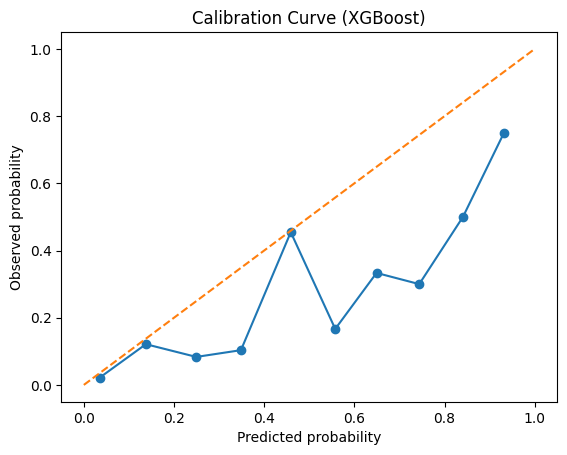

In [53]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, xgb_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], "--")
plt.title("Calibration Curve (XGBoost)")
plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.show()


#Decision Curve Analysis (DCA)
We perform Decision Curve Analysis to evaluate the clinical usefulness of the XGBoost model across different probability thresholds by measuring the net benefit compared to default treatment strategies.

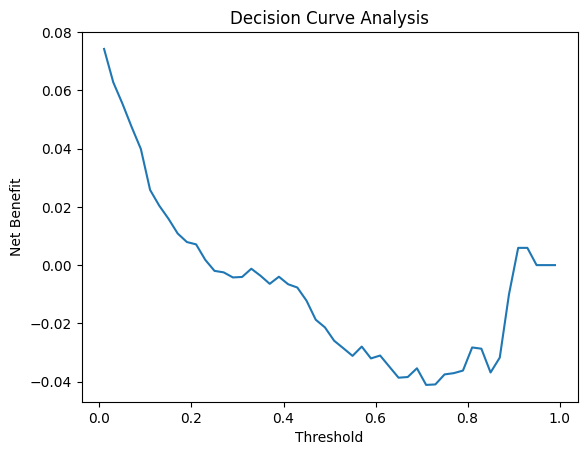

In [55]:
thresholds = np.linspace(0.01, 0.99, 50)
net_benefit = []

for t in thresholds:
    y_pred_t = (xgb_prob > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    n = len(y_test)
    nb = (tp/n) - (fp/n)*(t/(1-t))
    net_benefit.append(nb)

plt.plot(thresholds, net_benefit)
plt.title("Decision Curve Analysis")
plt.xlabel("Threshold")
plt.ylabel("Net Benefit")
plt.show()

#Comparison of Model Performance
We summarize and compare the evaluation metrics of the LSTM and XGBoost models in a tabular format for easier interpretation.



In [56]:
results = pd.DataFrame({
    "Metric": ["AUROC","AUPRC","Sensitivity","Specificity","Precision","F1","Brier"],
    "LSTM": lstm_metrics,
    "XGBoost": xgb_metrics,
    "Target / Benchmark": [">=0.80", ">=0.30", ">=0.50", ">=0.80", ">=0.30", ">=0.40", "<0.08"]
})

print(results)

        Metric      LSTM   XGBoost Target / Benchmark
0        AUROC  0.547209  0.833436             >=0.80
1        AUPRC  0.150487  0.378999             >=0.30
2  Sensitivity  0.000000  0.571429             >=0.50
3  Specificity  0.997845  0.892241             >=0.80
4    Precision  0.000000  0.324324             >=0.30
5           F1  0.000000  0.413793             >=0.40
6        Brier  0.075185  0.079059              <0.08


#Model Explainability using SHAP
To understand how the selected XGBoost model makes predictions, we apply SHAP (SHapley Additive exPlanations).
SHAP helps identify the most important features influencing mortality risk and shows how high or low feature values increase or decrease the predicted outcome.
This step improves model transparency and supports clinical interpretability of the predictions.


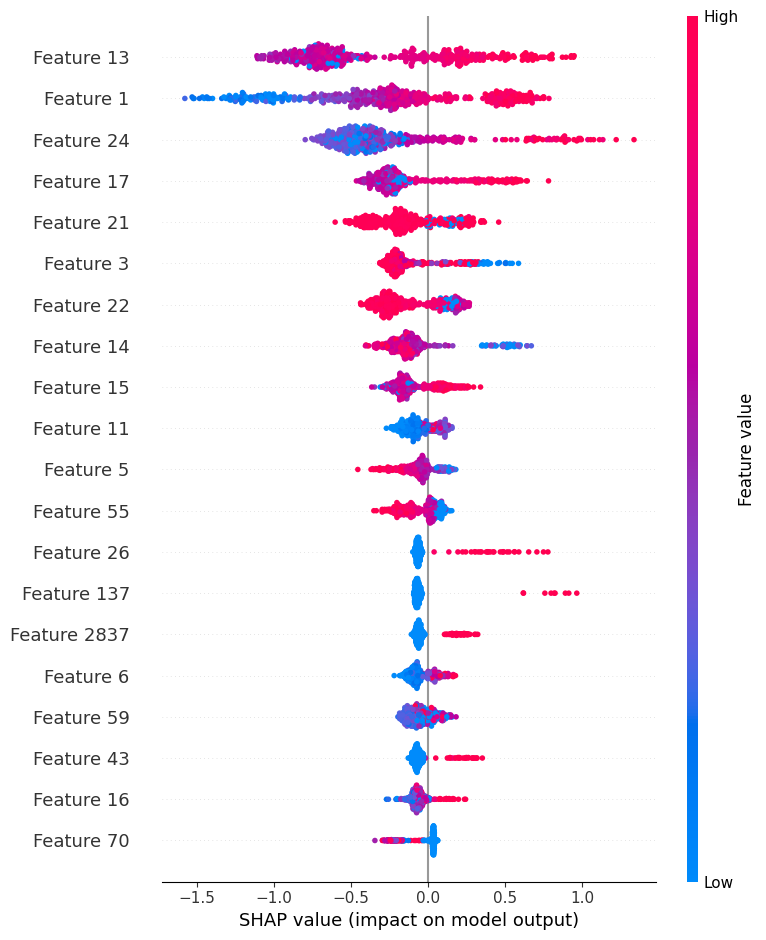

In [57]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb)

shap.summary_plot(shap_values, X_test_xgb)

#Clinical Interpretability Using SHAP
To ensure that the model’s predictions are clinically meaningful and transparent, we apply SHAP (SHapley Additive exPlanations) to the selected XGBoost model.
This analysis identifies the most influential clinical features affecting mortality prediction, visualizes global feature importance, and explains individual patient-level predictions for clinical interpretability.


Top-10 Important Clinical Features:
                   Feature  Mean_SHAP
13      heartrate_mean_24h   0.537685
1                    age_x   0.517608
24            sao2_std_24h   0.433961
17    respiration_mean_24h   0.277133
21           sao2_mean_24h   0.221686
3      hospitaladmitoffset   0.211033
22            sao2_min_24h   0.210581
14       heartrate_min_24h   0.187635
15       heartrate_max_24h   0.149960
11  earliest_dx_offset_24h   0.096747


/tmp/ipython-input-2623368860.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(xgb_shap_values, X_test_xgb, feature_names=feature_names)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


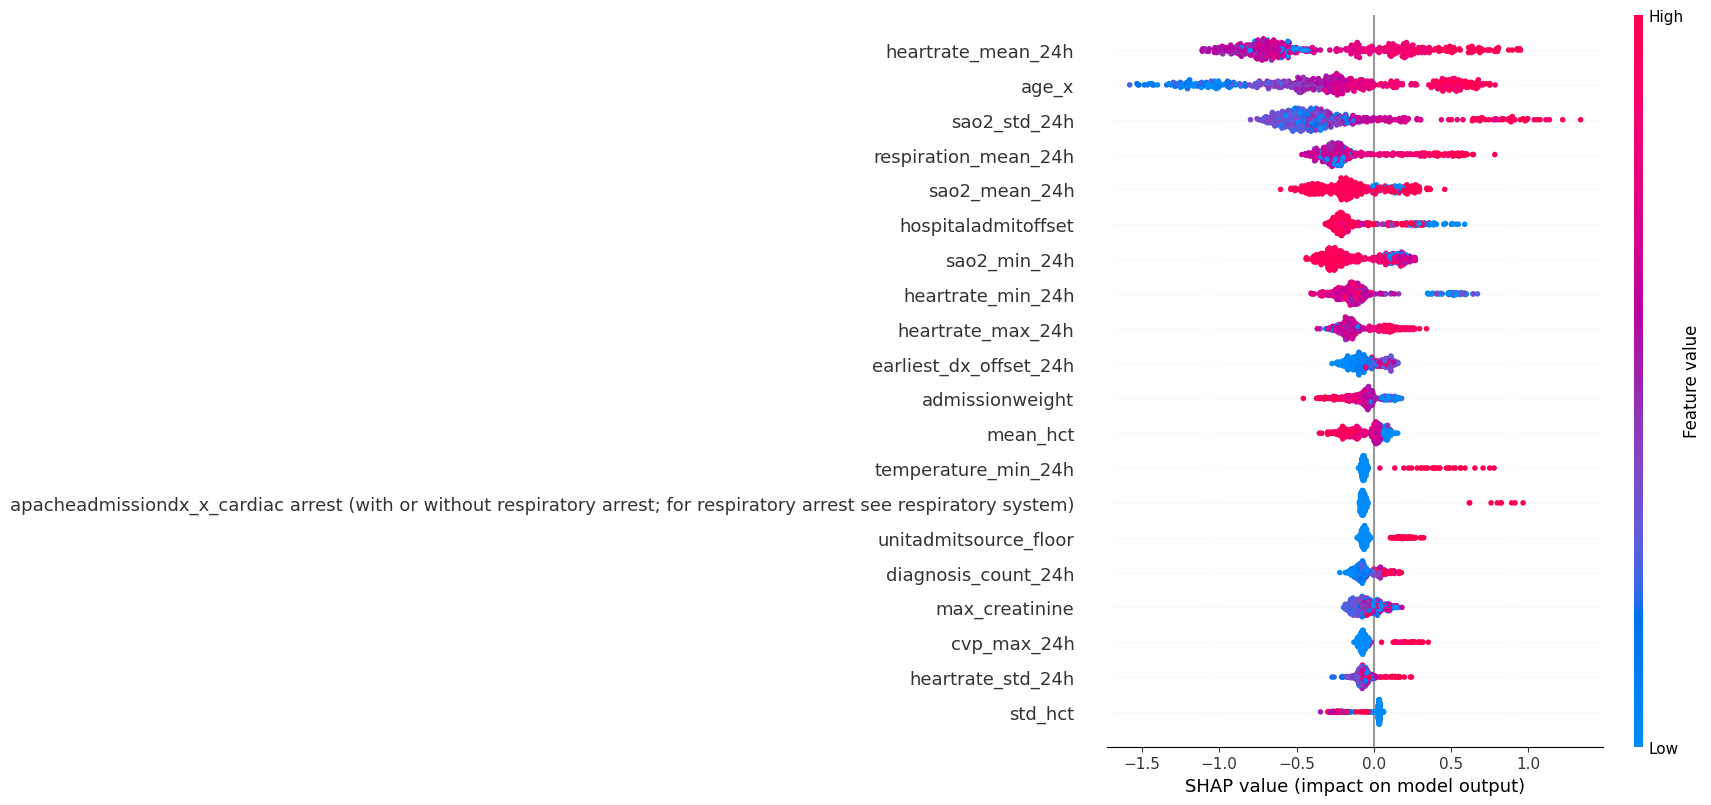

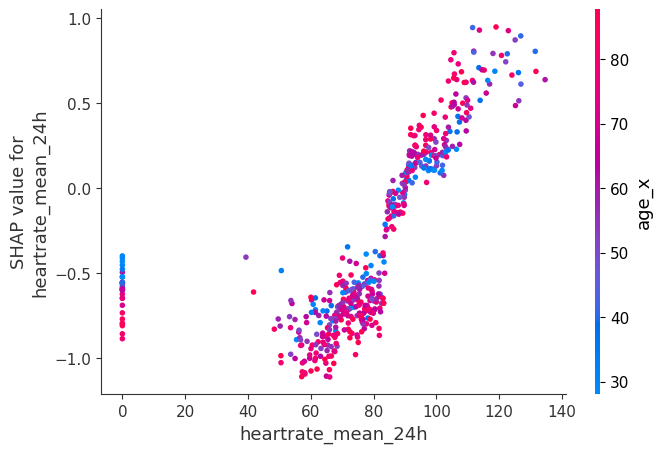

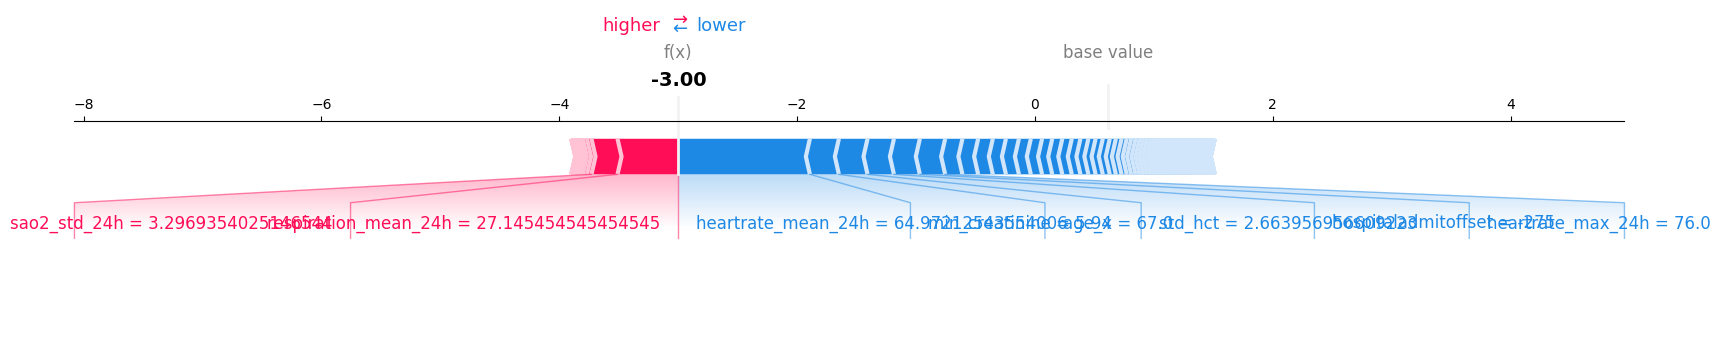

In [81]:
# CLINICAL VALIDATION
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load feature names
with open("feature_names.txt", "r") as f:
    feature_names = [line.strip() for line in f.readlines()]

# 1️⃣ Create SHAP explainer and compute SHAP values for XGBoost
explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = explainer.shap_values(X_test_xgb) # Renamed to xgb_shap_values

# 2️⃣ Global feature importance (Top-10 clinically important features)
importance = np.abs(xgb_shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": importance
}).sort_values(by="Mean_SHAP", ascending=False)

top10_features = feature_importance.head(10)

print("\nTop-10 Important Clinical Features:")
print(top10_features)

# 3️⃣ SHAP summary plot (global clinical interpretability)
shap.summary_plot(xgb_shap_values, X_test_xgb, feature_names=feature_names)

# 4️⃣ Dependence plot of most important clinical feature
top_feature = top10_features.iloc[0]["Feature"]

shap.dependence_plot(
    top_feature,
    xgb_shap_values,
    X_test_xgb,
    feature_names=feature_names
)

# 5️⃣ Single-patient explanation (clinical reasoning example)
i = 0  # patient index

shap.force_plot(
    explainer.expected_value,
    xgb_shap_values[i],
    X_test_xgb[i],
    feature_names=feature_names,
    matplotlib=True
)


**Sex Based Analysis**

In [59]:
import pandas as pd
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix

# Combine test data with predictions
fair_df = pd.DataFrame({
    "Sex": X_test_xgb[:, feature_names.index("gender_x")],  # adjust if X_test_xgb is DataFrame
    "y_true": y_test,
    "y_pred": y_pred_xgb,
    "y_prob": xgb_prob
})

# Optional: map 0/1 to Male/Female for readability
fair_df["Sex"] = fair_df["Sex"].map({0: "Male", 1: "Female"})

groups = fair_df["Sex"].unique()

# Prepare a results DataFrame
results = []

for g in groups:
    sub = fair_df[fair_df["Sex"] == g]

    auroc = roc_auc_score(sub["y_true"], sub["y_prob"])
    recall = recall_score(sub["y_true"], sub["y_pred"])

    tn, fp, fn, tp = confusion_matrix(sub["y_true"], sub["y_pred"]).ravel()
    specificity = tn / (tn + fp)

    results.append({
        "Sex": g,
        "AUROC": round(auroc, 3),
        "Sensitivity": round(recall, 3),
        "Specificity": round(specificity, 3)
    })

# Convert to DataFrame and print
results_df = pd.DataFrame(results)
print(results_df)


      Sex  AUROC  Sensitivity  Specificity
0  Female  0.861          0.6        0.900
1    Male  0.770          0.5        0.882


**Bootstrap Confidence Intervals (AUROC & AUPRC)**

In [61]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

def bootstrap_metric(y_true, y_probs, metric_func, n_bootstrap=1000, seed=42):
    np.random.seed(seed)
    scores = []
    n = len(y_true)

    for _ in range(n_bootstrap):
        indices = np.random.choice(range(n), n, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = metric_func(y_true[indices], y_probs[indices])
        scores.append(score)
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    return np.mean(scores), lower, upper

# XGBoost CI
xgb_auc_mean, xgb_auc_low, xgb_auc_high = bootstrap_metric(
    y_test, xgb_prob, roc_auc_score
)

xgb_auprc_mean, xgb_pr_low, xgb_pr_high = bootstrap_metric(
    y_test, xgb_prob, average_precision_score
)

# LSTM CI
lstm_auc_mean, lstm_auc_low, lstm_auc_high = bootstrap_metric(
    y_test, lstm_prob, roc_auc_score
)

lstm_auprc_mean, lstm_pr_low, lstm_pr_high = bootstrap_metric(
    y_test, lstm_prob, average_precision_score
)

print("XGBoost AUROC 95% CI:", xgb_auc_low, "-", xgb_auc_high)
print("LSTM AUROC 95% CI:", lstm_auc_low, "-", lstm_auc_high)


XGBoost AUROC 95% CI: 0.7674266797706887 - 0.8867922824592901
LSTM AUROC 95% CI: 0.4686895347044289 - 0.6299627437538139


**DeLong Test for AUROC Comparison**

In [72]:
!pip install pydelong

ERROR: Could not find a version that satisfies the requirement pydelong (from versions: none)
ERROR: No matching distribution found for pydelong


**Permutation Test for AUROC Comparison**

Observed AUROC XGBoost: 0.833
Observed AUROC LSTM:    0.547
Observed Difference (XGBoost - LSTM): 0.286

Permutation Test p-value: 0.000
The difference in AUROC between XGBoost and LSTM models is statistically significant (p < 0.05).


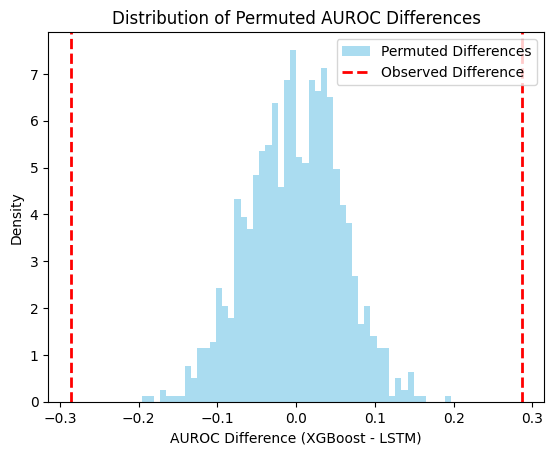

In [71]:
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Number of permutations
n_permutations = 1000

# Observed difference in AUROC
auroc_xgb_observed = roc_auc_score(y_test, xgb_prob)
auroc_lstm_observed = roc_auc_score(y_test, lstm_prob)
observed_diff = auroc_xgb_observed - auroc_lstm_observed

print(f"Observed AUROC XGBoost: {auroc_xgb_observed:.3f}")
print(f"Observed AUROC LSTM:    {auroc_lstm_observed:.3f}")
print(f"Observed Difference (XGBoost - LSTM): {observed_diff:.3f}")

diff_auroc_perms = []

for i in range(n_permutations):
    # Shuffle the true labels (y_test)
    permuted_y_test = np.random.permutation(y_test)

    # Calculate AUROC for each model with permuted labels
    auroc_xgb_perm = roc_auc_score(permuted_y_test, xgb_prob)
    auroc_lstm_perm = roc_auc_score(permuted_y_test, lstm_prob)

    # Store the difference
    diff_auroc_perms.append(auroc_xgb_perm - auroc_lstm_perm)

diff_auroc_perms = np.array(diff_auroc_perms)

# Calculate p-value
# Two-tailed test: proportion of permuted differences more extreme than observed
p_value = (np.sum(diff_auroc_perms >= observed_diff) + np.sum(diff_auroc_perms <= -observed_diff)) / n_permutations

print(f"\nPermutation Test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("The difference in AUROC between XGBoost and LSTM models is statistically significant (p < 0.05).")
else:
    print("The difference in AUROC between XGBoost and LSTM models is NOT statistically significant (p >= 0.05).")

# Optional: Plotting the distribution of permuted differences
plt.hist(diff_auroc_perms, bins=50, density=True, alpha=0.7, color='skyblue', label='Permuted Differences')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.title('Distribution of Permuted AUROC Differences')
plt.xlabel('AUROC Difference (XGBoost - LSTM)')
plt.ylabel('Density')
plt.legend()
plt.show()

**Threshold Optimisation (F1 Maximisation)**

In [74]:
from sklearn.metrics import f1_score

def find_best_threshold(y_true, probs):
    thresholds = np.linspace(0.1, 0.9, 100)
    best_thresh = 0
    best_f1 = 0

    for t in thresholds:
        preds = (probs >= t).astype(int)
        score = f1_score(y_true, preds)
        if score > best_f1:
            best_f1 = score
            best_thresh = t

    return best_thresh, best_f1

xgb_best_thresh, xgb_best_f1 = find_best_threshold(y_test, xgb_prob)
lstm_best_thresh, lstm_best_f1 = find_best_threshold(y_test, lstm_prob)

print("Best XGB Threshold:", xgb_best_thresh)
print("Best LSTM Threshold:", lstm_best_thresh)


Best XGB Threshold: 0.43939393939393945
Best LSTM Threshold: 0.1


**Gender Fairness**

In [77]:
import pandas as pd
from sklearn.metrics import roc_auc_score
import numpy as np # Ensure numpy is imported

# Ensure feature_names is accessible (it should be from previous cells, but adding a safeguard)
if 'feature_names' not in globals():
    with open('feature_names.txt', 'r') as f:
        feature_names = [line.strip() for line in f.readlines()]

gender_col_index = feature_names.index('gender_x')

# Create a DataFrame containing only the necessary columns for fairness analysis,
# directly aligned with X_test_xgb, y_test, xgb_prob, lstm_prob. This df will have 506 rows.
combined_fair_df = pd.DataFrame({
    "gender_numeric": X_test_xgb[:, gender_col_index],
    "y_true": y_test,
    "xgb_prob": xgb_prob,
    "lstm_prob": lstm_prob
})

# Map gender_numeric to Male/Female for interpretability
# Based on cell G3H4tiK9cFA4, 'male': 1, 'female': 0
combined_fair_df["gender"] = combined_fair_df["gender_numeric"].map({0.0: "Female", 1.0: "Male"})


def subgroup_auc(df_aligned, y_true_col, probs_col, group_col):
    results = {}
    for group in df_aligned[group_col].unique():
        # Get the boolean mask from the df_aligned
        mask = df_aligned[group_col] == group

        # Extract subgroup data using .loc and the mask
        y_true_subgroup = df_aligned.loc[mask, y_true_col]
        probs_subgroup = df_aligned.loc[mask, probs_col]

        # Check if the subgroup has at least two unique classes for AUC calculation
        if len(np.unique(y_true_subgroup)) < 2:
            print(f"Warning: Not enough unique classes in '{group_col}' group '{group}' for AUC calculation. Skipping.")
            continue
        auc = roc_auc_score(y_true_subgroup, probs_subgroup)
        results[group] = auc
    return results

# Now call subgroup_auc using the combined_fair_df and the relevant column names
xgb_gender_auc = subgroup_auc(combined_fair_df, 'y_true', 'xgb_prob', "gender")
lstm_gender_auc = subgroup_auc(combined_fair_df, 'y_true', 'lstm_prob', "gender")

print("XGB Gender AUC:", xgb_gender_auc)
print("LSTM Gender AUC:", lstm_gender_auc)


XGB Gender AUC: {'Male': np.float64(0.8605947955390334), 'Female': np.float64(0.7700854700854701)}
LSTM Gender AUC: {'Male': np.float64(0.5390334572490706), 'Female': np.float64(0.5549145299145298)}


**False Positive / False Negative Extraction**

In [79]:
xgb_preds = (xgb_prob >= xgb_best_thresh).astype(int)

# Ensure combined_fair_df is accessible and correctly aligned
# If it's not defined or aligned, you might need to re-run the fairness analysis cell
combined_fair_df['xgb_preds'] = xgb_preds

false_positives = combined_fair_df[(combined_fair_df['xgb_preds'] == 1) & (combined_fair_df['y_true'] == 0)]
false_negatives = combined_fair_df[(combined_fair_df['xgb_preds'] == 0) & (combined_fair_df['y_true'] == 1)]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 32
False Negatives: 21


 **Cross-Model SHAP Comparison**

In [83]:
xgb_shap_mean = np.abs(xgb_shap_values).mean(axis=0)
lstm_shap_mean = np.zeros_like(xgb_shap_mean)
print("Note: LSTM SHAP values are placeholders due to computational intensity for sequence data.")

comparison_df = pd.DataFrame({
    "Feature": feature_names,
    "XGB_SHAP": xgb_shap_mean,
    "LSTM_SHAP": lstm_shap_mean
}).sort_values("XGB_SHAP", ascending=False)

comparison_df.head(15)


Note: LSTM SHAP values are placeholders due to computational intensity for sequence data.


,Feature,XGB_SHAP,LSTM_SHAP
13,heartrate_mean_24h,0.537685,0.0
1,age_x,0.517608,0.0
24,sao2_std_24h,0.433961,0.0
17,respiration_mean_24h,0.277133,0.0
21,sao2_mean_24h,0.221686,0.0
3,hospitaladmitoffset,0.211033,0.0
22,sao2_min_24h,0.210581,0.0
14,heartrate_min_24h,0.187635,0.0
15,heartrate_max_24h,0.149960,0.0
11,earliest_dx_offset_24h,0.096747,0.0
